<a href="https://colab.research.google.com/github/marcelo-red/miniguia-estudos-notebooklm-Intelig-ncia-Artificial-Aplicada-no-Saneamento-B-sico/blob/main/C%C3%B3pia_de_Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteccção de Fraudes em Transações Bancarias

In [ ]:
import pandas as pd

url = url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#Problema de Classificação Desbalanceada

Fraudes são raras







In [ ]:
df["Class"].value_counts(normalize=True)


,proportion
Class,
0,0.998273
1,0.001727




#Feature Engineering

criando variáveis que ajudam no modelo




In [ ]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])


In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop("Class" , axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
     x,y, stratify=y, test_size=0.3, random_state=42
)



#Logistic Regression




In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



#Accuracy pode ser alta mesmo sem detectar fraudes.

Por isso usamos:

Recall (mais importante)
Precision
F1 -score




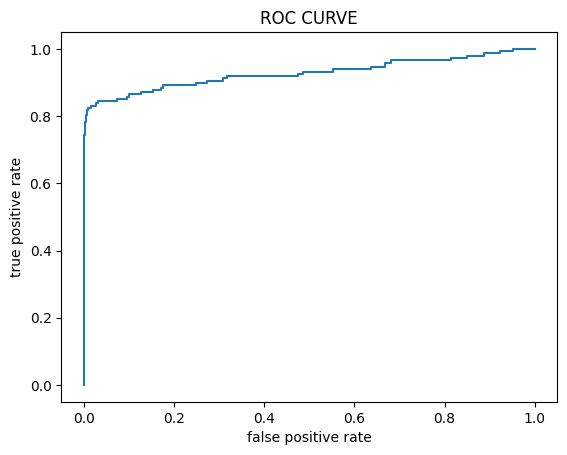

AUC:  0.9272042339543365


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC CURVE")
plt.xlabel( "false positive rate" )
plt.ylabel( "true positive rate" )
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs))

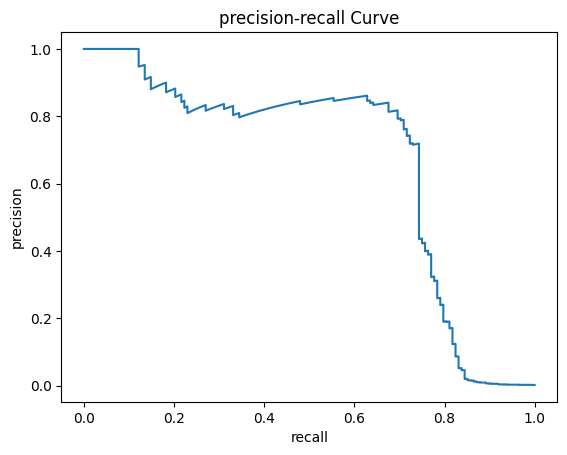

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("precision-recall Curve")
plt.xlabel("recall")
plt.ylabel("precision")
plt.show()

#Balanceamento de dados



In [ ]:
# Undersampling
fraudes = df[df["Class"] ==1]
normais = df[df["Class"] ==0].sample(len(fraudes), random_state =42)

df_under = pd.concat([fraudes, normais])

In [ ]:
#oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    (" scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [ ]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443




#Modelo Avançado _XGBoost

XGBoost é umdos algoritimos mais usados em competições e mercado
ele é mais poderoso que o Random Forest para muitos problemas




In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,  # ajuda com desbalanceamento
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)





In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443





* Importância das Variáveis


Ajuda a entender quais variáveis influenciam mais o modelo.



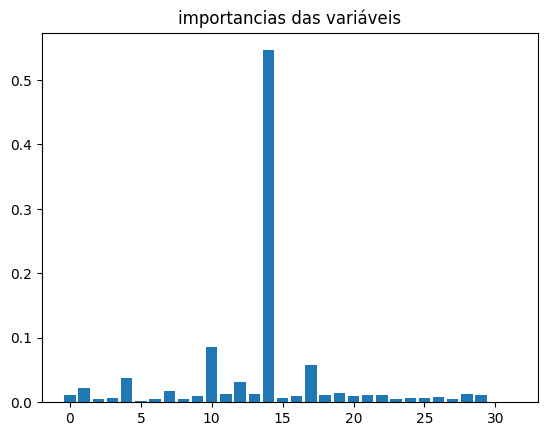

In [ ]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("importancias das variáveis")
plt.show()



#Ajuste de hiperparâmetros

Testamos váriascombinações para melhorar o modelo



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth" : [3, 5, 7],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("melhor modelo:", grid.best_params_)

melhor modelo: {'max_depth': 7, 'n_estimators': 100}




#Explicabilidade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo.




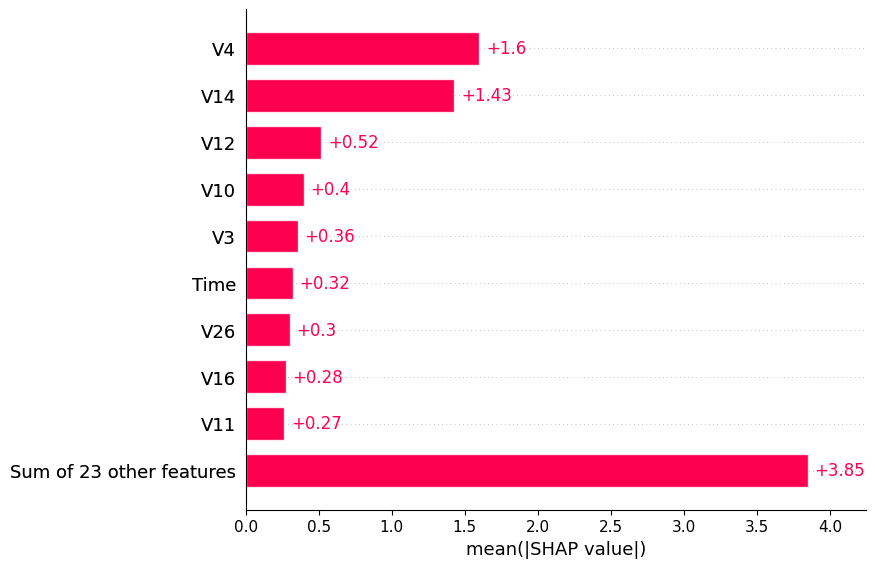

In [ ]:
explainer = shap.Explainer (xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)